In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
from phisat2.data_loaders import build_datamodule
from phisat2.tasks import resolve_task_spec
from phisat2.utils.seed import seed_everything
from phisat2.utils.visualization import visualize_triplet_batch

In [3]:
ROOT_DIR = "/lustre/home/u10010021/phisat2/data/triplets"
BATCH_SIZE = 4              
SEED = 42

In [3]:
BATCH_SIZE = 4              
SEED = 42

seed_everything(SEED)

spec = resolve_task_spec("pretrain_reconstruction", "ssl4eo")

datamodule = build_datamodule(
    "ssl4eo",
    root_dir="/lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked",
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=SEED,
    crop_size=256,
    fast_dev_run=False
)
datamodule.setup(stage="fit")
test_loader = datamodule.train_dataloader()

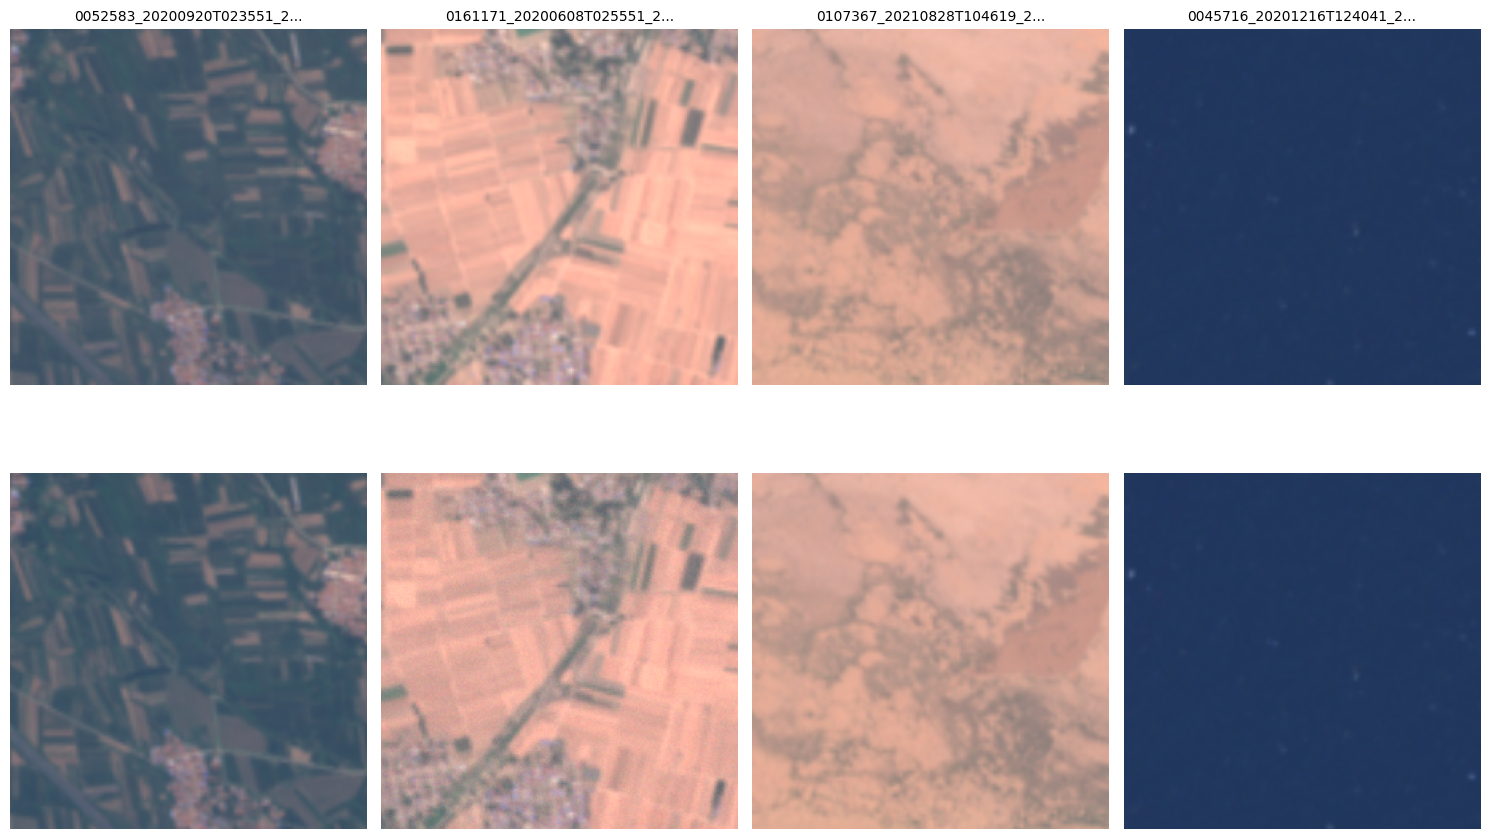

In [6]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from phisat2.data_loaders.sensors import get_norm_tensors, S2_BANDS

# 1. On pioche un batch du test_loader
for i,batch in enumerate(test_loader):
    images = batch["sentinel2"]
    images_aug = batch["sentinel2_augmented"]  # Shape: (B, 13, 224, 224)
    image_ids = batch["image_id"]
    if i > 10:
        break

# 2. On récupère les tenseurs de moyenne et écart-type pour faire l'inverse
s2_mean, s2_std = get_norm_tensors("s2", S2_BANDS)

# On reshape (13, 1, 1) pour que le calcul s'applique sur toute l'image
s2_mean = s2_mean.view(13, 1, 1)
s2_std = s2_std.view(13, 1, 1)

# Configuration de l'affichage
batch_size_to_show = min(4, images.shape[0])
fig, axes = plt.subplots(2, batch_size_to_show, figsize=(15, 10))
if batch_size_to_show == 1: axes = [axes]

for i in range(batch_size_to_show):
    img_tensor = images[i]
    
    # --- LA MAGIE EST ICI ---
    # A. Dé-normalisation : on repasse dans l'espace L1C [0, ~10000]
    img_unnorm = (img_tensor * s2_std) + s2_mean
    img_aug_unnorm = (images_aug[i] * s2_std) + s2_mean
    
    # B. Extraction des bandes RGB 
    # Dans la liste S2_BANDS, B4(Red) est à l'index 3, B3(Green) à l'index 2, B2(Blue) à l'index 1
    r = img_unnorm[3].numpy()
    g = img_unnorm[2].numpy()
    b = img_unnorm[1].numpy()
    
    rgb = np.dstack((r, g, b))
    
    rgb2 = np.dstack((img_aug_unnorm[3].numpy(), img_aug_unnorm[2].numpy(), img_aug_unnorm[1].numpy()))
    
    # C. Coupure pour l'affichage (L1C standard : on divise par 3000)
    rgb_display = np.clip(rgb / 3000.0, 0, 1)
    rgb2_display = np.clip(rgb2 / 3000.0, 0, 1)
    # ------------------------
    
    axes[0][i].imshow(rgb_display)
    
    # Titre un peu raccourci
    short_title = image_ids[i][:25] + "..." if len(image_ids[i]) > 25 else image_ids[i]
    axes[0][i].set_title(short_title, fontsize=10)
    axes[0][i].axis("off")
    
    axes[1][i].imshow(rgb2_display)
    axes[1][i].axis("off")
    

plt.tight_layout()
plt.show()

In [25]:
img_unnorm[10].min(), img_unnorm[10].max()  # Vérification des valeurs de la bande B11 (SWIR)

(tensor(9.0001), tensor(18.))

In [4]:
def enhance_contrast(rgb_img, p_low=2, p_high=98):
    """
    Applique un étirement de contraste (percentile stretch) canal par canal
    pour retirer le voile atmosphérique des images L1C.
    """
    enhanced = np.zeros_like(rgb_img)
    for i in range(3): # Pour les canaux R, G, B
        band = rgb_img[:, :, i]
        low, high = np.percentile(band, (p_low, p_high))
        # On évite la division par zéro avec 1e-5
        enhanced[:, :, i] = np.clip((band - low) / (high - low + 1e-5), 0, 1)
    return enhanced

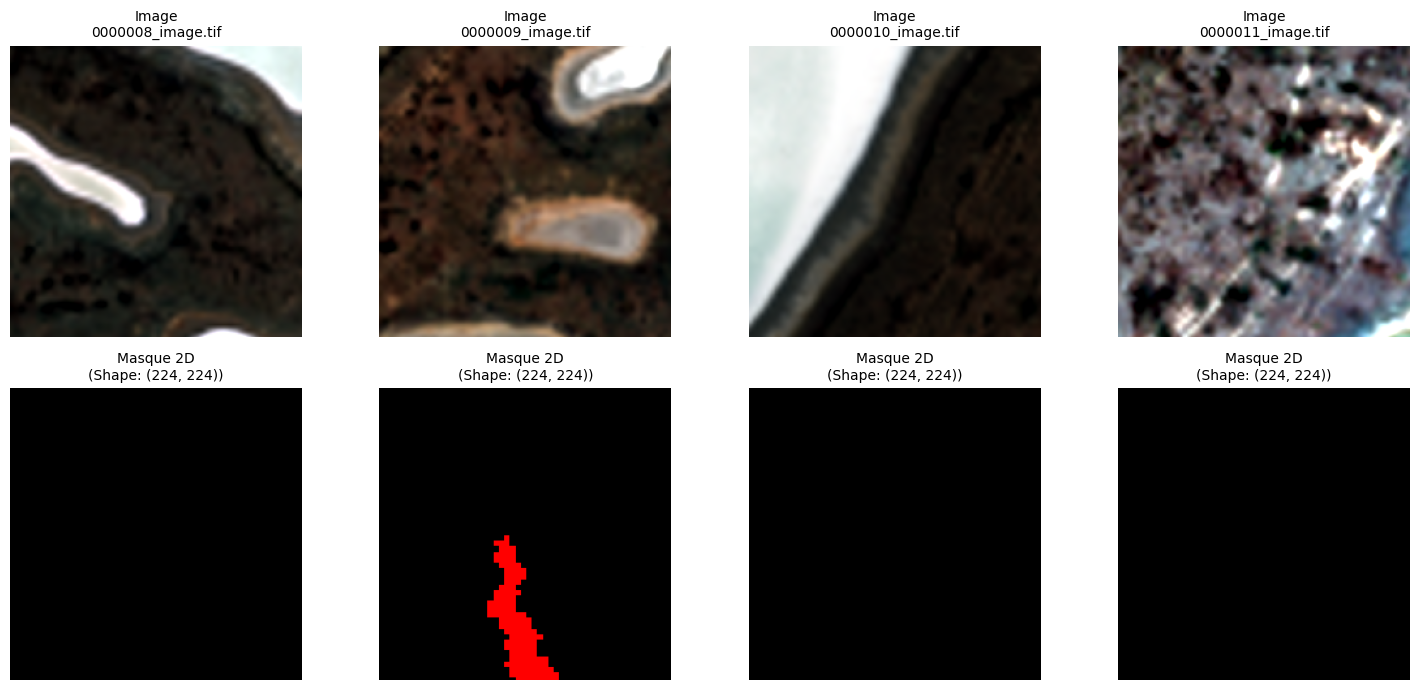

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import numpy as np
from phisat2.data_loaders.sensors import get_norm_tensors, S2_BANDS
from phisat2.tasks.specs import resolve_task_spec
from phisat2.data_loaders.downstream_s2 import IGNORE_INDEX_MAP

# ==========================================
# 1. CONFIGURATION DU TEST
# ==========================================
# Remplace par "clouds", "floods", "lulc", "marine" ou "methane"
TEST_DATASET = "methane" 
BATCH_SIZE = 4

# Dictionnaire des couleurs (pour l'affichage des masques)
DATASETS_COLORS = {
    "clouds": {0: "#419bdf", 1: "#ffffff", 2: "#d3d3d3", 3: "#2c2c2c", 255: "#000000"},
    "floods": {0: "#000000", 1: "#397d49", 2: "#0000FF", 3: "#ffffff", 255: "#000000"},
    "lulc": {0: "#000000", 1: "#419bdf", 2: "#397d49", 3: "#88b053", 4: "#7a87c6", 
               5: "#e49635", 6: "#dfc35a", 7: "#c4281b", 8: "#a59b8f", 9: "#b39fe1", 10: "#ffffff", 255: "#000000"},
    "marine": {0: "#000000", 1: "#0000CD", 2: "#8B4513", 3: "#228B22", 4: "#FF00FF", 
               5: "#4F4F4F", 6: "#00FF00", 7: "#D2B48C", 8: "#FFFFFF", 255: "#000000"},
    "methane": {0: "#000000", 1: "#FF0000", 255: "#000000"}
}

def label_to_rgb(label_mask, color_dict):
    """Convertit le masque 2D en image RGB avec les bonnes couleurs."""
    h_dim, w_dim = label_mask.shape
    rgb_mask = np.zeros((h_dim, w_dim, 3), dtype=np.float32)
    for val, hex_color in color_dict.items():
        hex_color = hex_color.lstrip('#')
        r, g, b = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
        rgb_mask[label_mask == val] = [r, g, b]
    return rgb_mask

# ==========================================
# 2. CHARGEMENT VIA LE DATAMODULE
# ==========================================
# Création d'un mock TaskSpec (si resolve_task_spec a besoin d'un nom de task valide)
spec = resolve_task_spec("segmentation", TEST_DATASET)

# Construction du DataModule en utilisant ta fonction build_datamodule
# (Assure-toi que "downstream" pointe bien vers ton nouveau module dans ton REGISTRY)
datamodule = build_datamodule(
    name="downstream_s2",
    root_dir="/lustre/home/u10010021/phisat2/data",
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=42,
    crop_size=224,
    fast_dev_run=False
)

# On prépare pour l'entraînement (pour tester les augmentations et le crop)
datamodule.setup(stage="test")
train_loader = datamodule.test_dataloader()

# ==========================================
# 3. EXTRACTION ET AFFICHAGE
# ==========================================
for i, batch in enumerate(train_loader):
    images = batch["sentinel2"] # Shape (B, 13, 224, 224)
    masks = batch["mask"]       # Shape (B, 224, 224)
    image_ids = batch["image_id"]
    if i >= 2:
        break  # On ne prend que les 10 premiers batches pour l'affichage

# Récupération pour la dé-normalisation
s2_mean, s2_std = get_norm_tensors("s2", S2_BANDS)
s2_mean = s2_mean.view(13, 1, 1)
s2_std = s2_std.view(13, 1, 1)

cfg_colors = DATASETS_COLORS[TEST_DATASET]
batch_size_to_show = min(4, images.shape[0])

fig, axes = plt.subplots(2, batch_size_to_show, figsize=(15, 7))
if batch_size_to_show == 1:
    axes = np.expand_dims(axes, axis=1)

for i in range(batch_size_to_show):
    # --- Traitement de l'Image L1C ---
    img_unnorm = (images[i] * s2_std) + s2_mean
    r = img_unnorm[3].numpy()
    g = img_unnorm[2].numpy()
    b = img_unnorm[1].numpy()
    rgb = np.dstack((r, g, b))
    rgb = enhance_contrast(rgb, p_low=2, p_high=98)
    
    # Ligne 1 : Image
    axes[0, i].imshow(rgb)
    short_title = image_ids[i][:20] + "..." if len(image_ids[i]) > 20 else image_ids[i]
    axes[0, i].set_title(f"Image\n{short_title}", fontsize=10)
    axes[0, i].axis("off")
    
    # --- Traitement du Masque ---
    mask_np = masks[i].numpy()
    rgb_mask = label_to_rgb(mask_np, cfg_colors)
    
    # Ligne 2 : Masque
    axes[1, i].imshow(rgb_mask)
    axes[1, i].set_title(f"Masque 2D\n(Shape: {mask_np.shape})", fontsize=10)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [28]:
image = batch["sentinel2"][0]

In [29]:
import matplotlib.pyplot as plt
import numpy as np

In [30]:
p2, p98 = np.percentile(image, (2, 98))
image = np.clip((image - p2) / (p98 - p2), 0, 1)

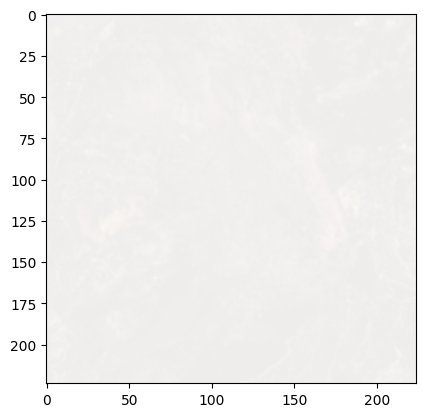

In [31]:
plt.imshow(image.permute(1, 2, 0)[..., (3, 2, 1)])  # Displaying RGB channels (BGR to RGB)

In [4]:
seed_everything(SEED)

spec = resolve_task_spec("pretrain_reconstruction", "triplets")

datamodule = build_datamodule(
    "triplets",
    root_dir=ROOT_DIR,
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=SEED,
    crop_size=256,
    fast_dev_run=False
)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()

In [35]:
for i, batch in enumerate(test_loader):
    if i >= 10:
        break

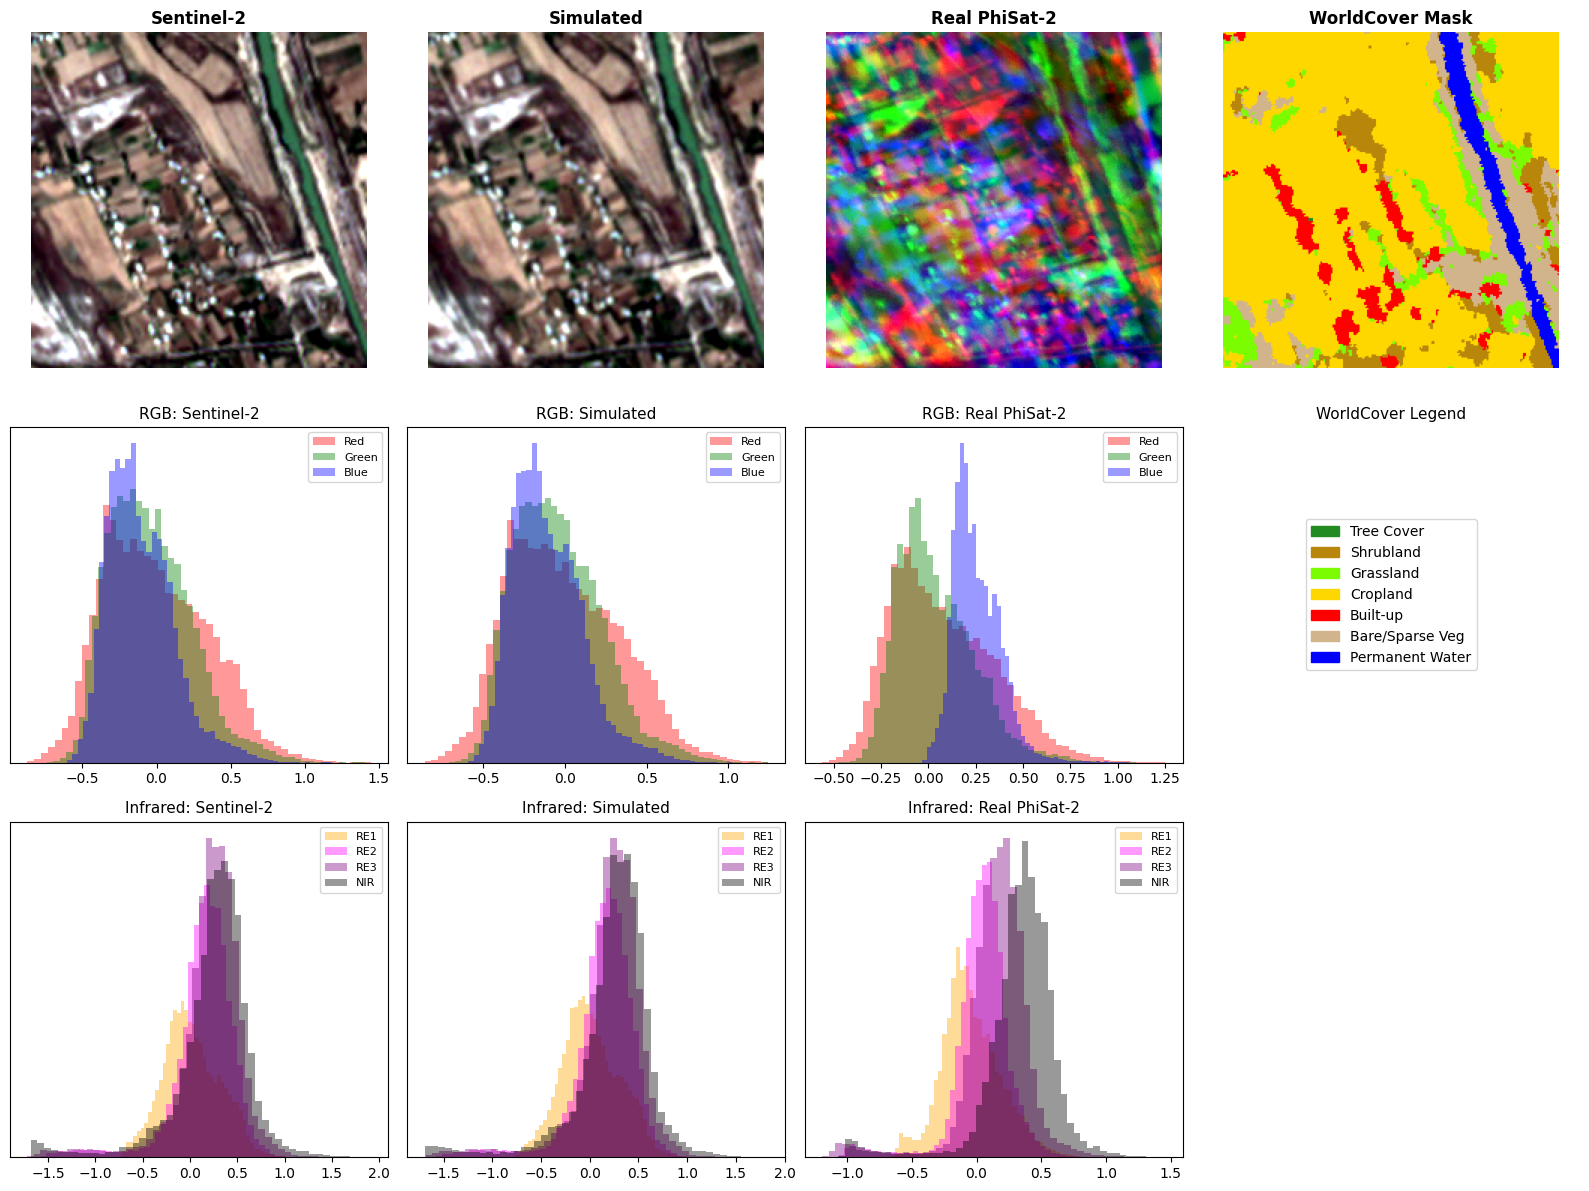

In [37]:
visualize_triplet_batch(batch, idx=0, show_cloud=False, show_worldcover=True)#,zoom_box=(100, 100, 150, 150))

In [62]:
import os
import glob
import random
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_DIR = "/lustre/scratch/1001/phisatnet_s2_datasets"

# Choix du dataset à afficher : "clouds", "floods", "lulc", "marine", ou "methane"
SELECTED_DATASET = "lulc"
NUM_SAMPLES = 10  # Nombre d'images à afficher

# Configuration exhaustive des datasets (Dossier, Classes, Couleurs HEX)
DATASETS_CONFIG = {
    "clouds": {
        "folder": "cloudsen_dataset_256",
        "classes": {0: "Clear", 1: "Thick Cloud", 2: "Thin Cloud", 3: "Cloud Shadow", 255: "No Data"},
        "colors": {0: "#419bdf", 1: "#ffffff", 2: "#d3d3d3", 3: "#2c2c2c", 255: "#000000"}
    },
    "floods": {
        "folder": "worldfloods_dataset_256",
        "classes": {0: "Invalid/NoData", 1: "Land", 2: "Water", 3: "Clouds", 255: "Invalid/NoData"},
        "colors": {0: "#000000", 1: "#397d49", 2: "#0000FF", 3: "#ffffff", 255: "#000000"}
    },
    "lulc": {
        "folder": "dynamic_world_dataset_256",
        "classes": {0: "No Data", 1: "Water", 2: "Trees", 3: "Grass", 4: "Flooded Veg", 
                    5: "Crops", 6: "Scrub", 7: "Built Area", 8: "Bare Ground", 9: "Snow/Ice", 10: "Cloud", 255: "No Data"},
        "colors": {0: "#000000", 1: "#419bdf", 2: "#397d49", 3: "#88b053", 4: "#7a87c6", 
                   5: "#e49635", 6: "#dfc35a", 7: "#c4281b", 8: "#a59b8f", 9: "#b39fe1", 10: "#ffffff", 255: "#000000"}
    },
    "marine": {
        "folder": "marine_area_dataset_256",
        "classes": {0: "No Data", 1: "Clear Water", 2: "Turbid Water", 3: "Land", 4: "Plastic", 
                    5: "Oil", 6: "Algae", 7: "Sediments", 8: "Cloud", 255: "No Data"},
        "colors": {0: "#000000", 1: "#0000CD", 2: "#8B4513", 3: "#228B22", 4: "#FF00FF", 
                   5: "#4F4F4F", 6: "#00FF00", 7: "#D2B48C", 8: "#FFFFFF", 255: "#000000"}
    },
    "methane": {
        "folder": "geoch4_dataset_256",
        "classes": {0: "No Plume", 1: "Plume", 255: "No Data"},
        "colors": {0: "#000000", 1: "#FF0000", 255: "#000000"}
    }
}

# ==========================================
# 2. FONCTIONS UTILITAIRES
# ==========================================
def read_rgb(image_path):
    """Lecture classique en vraies couleurs (B4, B3, B2)."""
    with rio.open(image_path) as src:
        r = src.read(4).astype(np.float32)
        g = src.read(3).astype(np.float32)
        b = src.read(2).astype(np.float32)
    rgb = np.dstack((r, g, b))
    print(f"Lecture de l'image RGB : {image_path}, forme : {rgb.shape}, min : {rgb.min()}, max : {rgb.max()}")
    return np.clip(rgb / 3000.0, 0, 1), None # None = pas de colormap

def read_swir_ratio(image_path):
    """Lecture spécifique pour le méthane : Ratio B11 / B12."""
    with rio.open(image_path) as src:
        # Dans ton stack, B11 est l'index 12, B12 est l'index 13
        b11 = src.read(12).astype(np.float32)
        b12 = src.read(13).astype(np.float32)
    
    print(f"Lecture de l'image SWIR : {image_path}, forme : {b11.shape}, min : {b11.min()}, max : {b11.max()}")
    # On ajoute un epsilon pour éviter la division par zéro
    ratio = b11 / (b12 + 1e-5)
    
    # Pour que le contraste soit visible, on coupe les valeurs extrêmes (2% - 98%)
    p2, p98 = np.percentile(ratio, (2, 98))
    ratio_norm = np.clip((ratio - p2) / (p98 - p2), 0, 1)
    
    return ratio_norm, 'magma' # Utilisation de la colormap 'magma'

def label_to_rgb(label_mask, color_dict):
    """Convertit un masque 2D en image RGB basée sur les codes HEX."""
    h_dim, w_dim = label_mask.shape
    rgb_mask = np.zeros((h_dim, w_dim, 3), dtype=np.float32)
    for val, hex_color in color_dict.items():
        hex_color = hex_color.lstrip('#')
        r, g, b = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
        rgb_mask[label_mask == val] = [r, g, b]
    return rgb_mask

In [63]:
SELECTED_DATASET = "methane"

Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0004048_image.tif, forme : (256, 256), min : 1191.0, max : 5342.8125
Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0007914_image.tif, forme : (256, 256), min : 6494.0, max : 7933.25
Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0005412_image.tif, forme : (256, 256), min : 6408.6875, max : 7666.25
Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0002631_image.tif, forme : (256, 256), min : 6699.0625, max : 7748.25
Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0007132_image.tif, forme : (256, 256), min : 3362.6875, max : 6031.0
Lecture de l'image SWIR : /lustre/scratch/1001/phisatnet_s2_datasets/geoch4_dataset_256/train/images/0002030_image.tif, forme : (256, 256), min : 1365

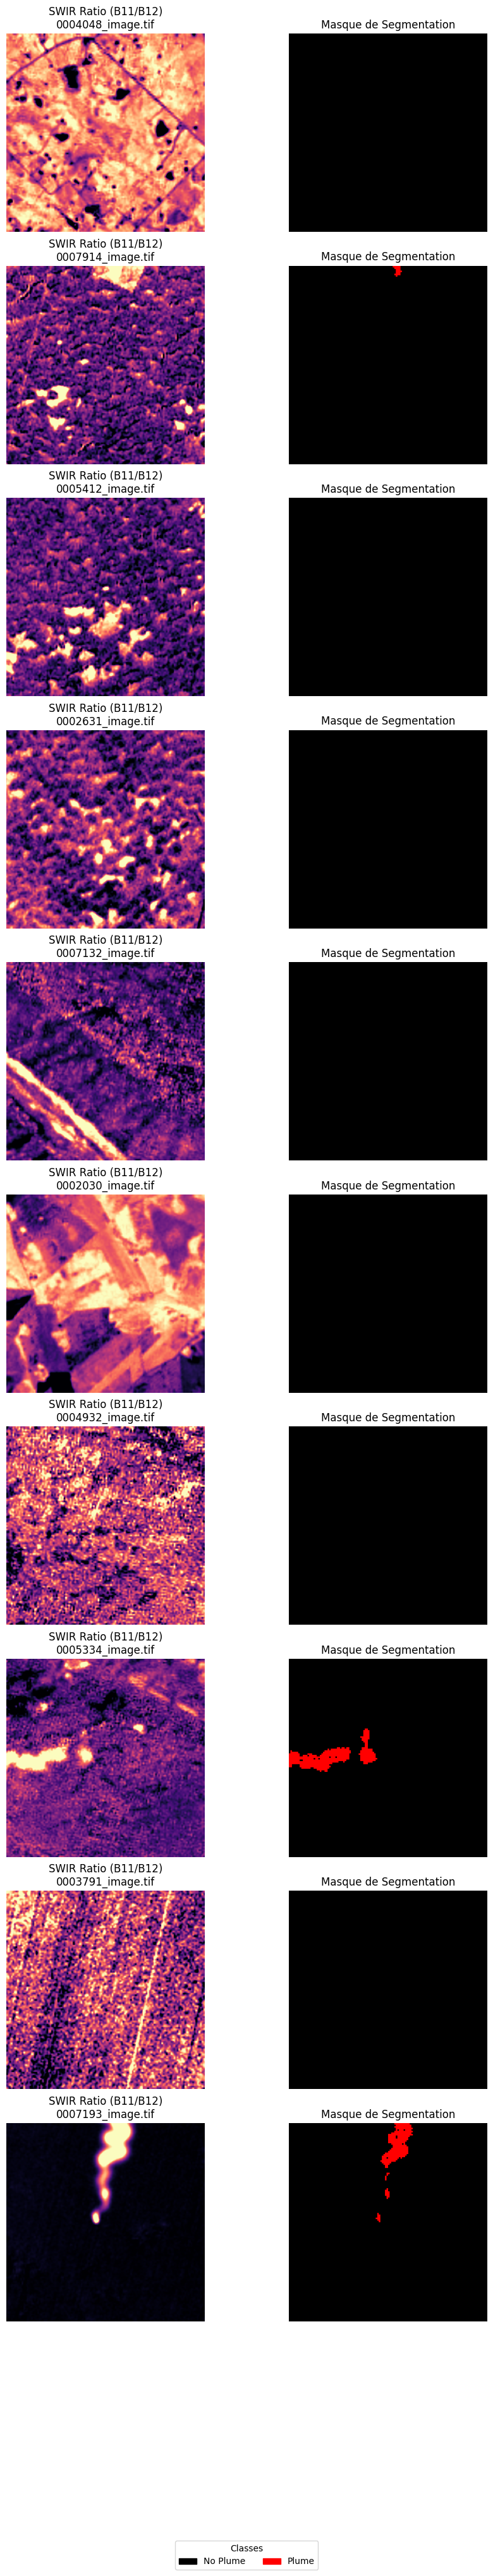

In [64]:
cfg = DATASETS_CONFIG[SELECTED_DATASET]
images_dir = os.path.join(BASE_DIR, cfg["folder"], "train", "images")
labels_dir = os.path.join(BASE_DIR, cfg["folder"], "train", "labels")

all_images = glob.glob(os.path.join(images_dir, "*_image.tif"))

if not all_images:
    print(f"❌ Aucune image trouvée dans {images_dir}")
else:
    samples = random.sample(all_images, min(NUM_SAMPLES, len(all_images)))
    
    fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(10, 4 * NUM_SAMPLES))
    #fig.suptitle(f"Exploration du Dataset : {SELECTED_DATASET.upper()}", fontsize=18, y=0.98)
    
    if NUM_SAMPLES == 1:
        axes = [axes]
        
    for i, img_path in enumerate(samples):
        filename = os.path.basename(img_path)
        lbl_path = os.path.join(labels_dir, filename.replace('_image.tif', '_label.tif'))
        
        # --- Image L1C (RGB ou Ratio SWIR) ---
        if SELECTED_DATASET == "methane":
            img_data, cmap = read_swir_ratio(img_path)
            axes[i][0].imshow(img_data, cmap=cmap)
            axes[i][0].set_title(f"SWIR Ratio (B11/B12)\n{filename}")
        else:
            img_data, cmap = read_rgb(img_path)
            axes[i][0].imshow(img_data)
            axes[i][0].set_title(f"RGB True Color\n{filename}")
            
        axes[i][0].axis('off')
        
        # --- Masque Label ---
        if os.path.exists(lbl_path):
            with rio.open(lbl_path) as src:
                label_img = src.read(1)
            rgb_label = label_to_rgb(label_img, cfg["colors"])
            axes[i][1].imshow(rgb_label)
            axes[i][1].set_title(f"Masque de Segmentation")
        else:
            axes[i][1].text(0.5, 0.5, "Label introuvable", ha='center')
        axes[i][1].axis('off')

    # --- Légende ---
    legend_patches = [mpatches.Patch(color=hex_color, label=cfg["classes"][val])
                      for val, hex_color in cfg["colors"].items() if val != 255]
    fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches)//2 + 1, 
               bbox_to_anchor=(0.5, -0.02), title="Classes", fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()

Lecture de /lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked/train/0215403_20200910T082609_20200910T083443_T36SWG_image.tif : shape=(264, 264, 3), min=773.0, max=4248.0
Lecture de /lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked/train/0011768_20210717T100559_20210717T101305_T32SLE_image.tif : shape=(264, 264, 3), min=1165.0, max=4551.0
Lecture de /lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked/train/0140649_20210224T081829_20210224T082246_T37SCA_image.tif : shape=(264, 264, 3), min=504.0, max=4772.0
Lecture de /lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked/train/0112825_20200902T163901_20200902T165715_T15QVV_image.tif : shape=(264, 264, 3), min=271.0, max=6065.0


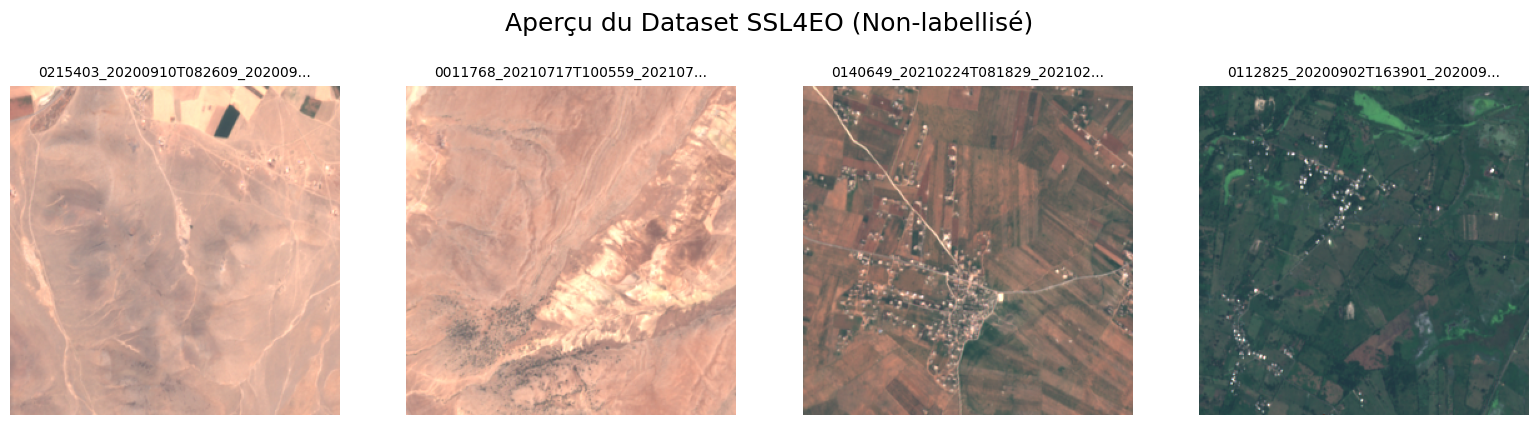

In [50]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
# J'utilise recursive=True dans le glob au cas où tes images 
# seraient directement dans /train ou dans /train/images/
SSL4EO_DIR = "/lustre/scratch/1001/phisatnet_s2_datasets/ssl4eo_dataset_stacked/train"
NUM_SAMPLES = 4  # Nombre d'images à afficher côte à côte

# ==========================================
# 2. FONCTION DE LECTURE RGB
# ==========================================
def read_rgb(image_path):
    """Extrait les bandes B4(Red), B3(Green), B2(Blue) et normalise pour l'affichage."""
    with rio.open(image_path) as src:
        # B4 = index 4, B3 = index 3, B2 = index 2 (dans ton stack B1 à B12)
        r = src.read(4).astype(np.float32)
        g = src.read(3).astype(np.float32)
        b = src.read(2).astype(np.float32)
        
    rgb = np.dstack((r, g, b))
    print(f"Lecture de {image_path} : shape={rgb.shape}, min={rgb.min()}, max={rgb.max()}")
    # Normalisation visuelle Sentinel-2 L1C (on coupe à 3000)
    return np.clip(rgb / 3000.0, 0, 1)

# ==========================================
# 3. AFFICHAGE DES PATCHS
# ==========================================
# Recherche de tous les fichiers terminant par _image.tif
all_images = glob.glob(os.path.join(SSL4EO_DIR, "**", "*_image.tif"), recursive=True)

if not all_images:
    print(f"❌ Aucune image trouvée dans {SSL4EO_DIR}")
else:
    # Tirage aléatoire
    samples = random.sample(all_images, min(NUM_SAMPLES, len(all_images)))
    
    # Création d'une grille 1 ligne / NUM_SAMPLES colonnes
    fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(4 * NUM_SAMPLES, 4))
    fig.suptitle("Aperçu du Dataset SSL4EO (Non-labellisé)", fontsize=18, y=1.05)
    
    # Sécurité si on ne demande qu'une seule image
    if NUM_SAMPLES == 1:
        axes = [axes]
        
    for i, img_path in enumerate(samples):
        filename = os.path.basename(img_path)
        
        try:
            # --- Image RGB ---
            axes[i].imshow(read_rgb(img_path))
            
            # On raccourcit un peu le titre s'il est trop long
            short_name = filename[:30] + "..." if len(filename) > 30 else filename
            axes[i].set_title(f"{short_name}", fontsize=10)
        except Exception as e:
            axes[i].set_title(f"Erreur RGB: {e}", fontsize=10)
            
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()